<a href="https://colab.research.google.com/github/GuilhermeMBertolo/Predicao_ataques_redescorporativas/blob/main/NSL_KDD_KNN_%E2%80%94_K_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predição de ataques em redes corporativas**

---

## Definição do problema

---



O dataset NSL-KDD contém informações sobre conexões de rede, abrangendo variáveis relacionadas a protocolos, serviços, status de pacotes e características de tráfego. O conjunto é composto por registros classificados como tráfego normal ou ataques de diferentes tipos, incluindo Denial of Service (DoS), Probe, Remote to Local (R2L) e User to Root (U2R).

O objetivo é analisar como essas características influenciam a ocorrência de intrusões e desenvolver modelos capazes de detectar automaticamente atividades maliciosas em redes de computadores. Esse cenário é formalizado como um problema de classificação supervisionada, sendo amplamente utilizado para treinar e avaliar técnicas de Machine Learning aplicadas à segurança da informação.

Nesse trabalho, os diferentes tipos de ataque foram unificados na categoria “ataque”, de forma que o objetivo passou a ser prever se uma conexão é maliciosa ou não, sem distinguir entre os tipos específicos de ataque.

##Premissas
Assume-se que existe uma relação sistemática entre as características das conexões de rede e a ocorrência de atividades maliciosas, de forma que os padrões podem ser aprendidos por um modelo de classificação supervisionada. Considera-se também que os dados do dataset NSL-KDD são suficientemente representativos do comportamento de tráfego de rede, abrangendo tanto interações legítimas quanto diferentes tipos de ataques, sem vieses que comprometam a análise. Além disso, presume-se que cada registro representa uma conexão independente, ou seja, o comportamento de uma sessão de rede não influencia diretamente o de outra. Outro ponto assumido é que as variáveis disponíveis no conjunto de dados são relevantes e capazes de explicar uma parcela significativa da variabilidade entre conexões normais e maliciosas, e que essas relações permanecem consistentes, permitindo a generalização dos modelos desenvolvidos para novos cenários de detecção de intrusão.

##Dataset


*   Fonte: Kaggle
*   Link: https://www.kaggle.com/datasets/hassan06/nslkdd/data
*   Atributos: O dataset NSL-KDD possui 41 variáveis independentes que descrevem diferentes características das conexões de rede, incluindo informações sobre protocolos, serviços, status de pacotes, conteúdo da comunicação e estatísticas de tráfego em janelas temporais. A variável dependente é o rótulo de classe, que indica se a conexão é normal ou corresponde a um ataque, categorizado em uma das quatro classes principais: DoS, Probe, R2L ou U2R.

## **1. Importando bibliotecas**

---



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve
)

warnings.filterwarnings("ignore")


### **2. Lendo o dataset**

---

O dataset é lido no Google Drive. No caminho Meu Drive/NSL KDD/.


In [ ]:
# ID do arquivo no Google Drive
file_id = "1nQ2Y1ByrFTje4P3uxdHNNKcC8oNXaWmu"

# Link direto de download
url = f"https://drive.google.com/uc?export=download&id={file_id}"

df = pd.read_csv(url, header=None)

# Número de linhas (registros)
n_row1 = df.shape[0]
print('Número de registros:', n_row1)

# Exibindo o DataFrame
df

Número de registros: 125973


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## **3. Preparação dos dados**

---

O dataset NSL-KDD é fornecido originalmente sem os nomes das colunas, sendo necessário atribuí-los manualmente antes de poder manipular e analisar os dados de forma eficaz.

Na etapa inicial de preparação dos dados, a variável alvo foi padronizada para “normal”, indicando uma conexão legítima, e “attack”, indicando a ocorrência de atividade maliciosa. Para isso, os quatro tipos distintos de ataque presentes no dataset foram unificados na categoria “attack”, garantindo consistência na análise.

Para a aplicação dos algoritmos de aprendizado de máquina, foi necessário realizar a etapa de pré-processamento, garantindo que todas as variáveis estivessem em formato numérico e adequadas para o treinamento dos modelos.
As variáveis categóricas foram convertidas para o números inteiros, assegurando uniformidade no conjunto de dados.

Por fim, todas as colunas do DataFrame, exceto outcome, foram atribuídas à variável X, representando os atributos que servirão como entrada para o modelo. A coluna outcome foi separada na variável Y, correspondendo à variável que se deseja prever.

Obs: Foi analisado que o dataset não possui atributos vazios, nem linhas duplicadas.

In [ ]:
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'])
df.columns = columns
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


In [ ]:
df.loc[df['outcome'] == "normal", "outcome"] = 'normal'
df.loc[df['outcome'] != 'normal', "outcome"] = 'attack'
df.outcome

,outcome
0,normal
1,normal
2,attack
3,normal
4,normal
...,...
125968,attack
125969,normal
125970,normal
125971,attack


In [ ]:
df['outcome'].unique()

array(['normal', 'attack'], dtype=object)

In [ ]:
cat_features = df.select_dtypes(include='object').columns
cat_features

Index(['protocol_type', 'service', 'flag', 'outcome'], dtype='object')

In [ ]:
le=preprocessing.LabelEncoder()
clm=['protocol_type', 'service', 'flag', 'outcome']
for x in clm:
    df[x]=le.fit_transform(df[x])

df[clm].head()

,protocol_type,service,flag,outcome
0,1,20,9,1
1,2,44,9,1
2,1,49,5,0
3,1,24,9,1
4,1,24,9,1


In [ ]:
X = df.drop(["outcome"], axis=1)
Y = df["outcome"]
print(Y.value_counts())

outcome
1    67343
0    58630
Name: count, dtype: int64


## **4. Selecionando melhores atributos**

---

Para analisar o impacto de cada variável na classificação, é possível calcular a importância de cada atributo em relação ao alvo, utilizando técnicas como informação mútua, que mede quanto cada feature ajuda a prever se a conexão é normal ou maliciosa. Um gráfico de barras ordenando as variáveis do mais para o menos relevante permite visualizar rapidamente quais atributos contribuem mais para a detecção de ataques.

Além disso, métodos de seleção de atributos, como ANOVA F (f_classif), podem ser usados para escolher as variáveis mais relevantes. Por exemplo, selecionando apenas as 17 variáveis mais significativas, reduz-se a dimensionalidade do dataset, simplificando o modelo e focando nos atributos que realmente impactam a classificação.

A escolha dos atributos mais importantes é fundamental, pois melhora o desempenho do modelo, reduz o tempo de treino, diminui o risco de overfitting e ajuda a interpretar quais características da rede são críticas para identificar ataques.

In [ ]:
names=list(X.columns)
# Seleção de atributos
n_selected=17 # Digitar aqui o número de atributos a serem selecionados
test = SelectKBest(score_func=f_classif, k=n_selected)
fit = test.fit(X, Y)
# summarize scores
np.set_printoptions(precision=3)
features = fit.transform(X)
# list(data) or
performance_list = pd.DataFrame(
    {'Attribute': names,
     'Value': fit.scores_
    })
performance_list=performance_list.sort_values(by=['Value'], ascending=False)
names_selected=performance_list.values[0:n_selected,0]

XX = pd.DataFrame (X, columns = names_selected)
X=XX
X

,same_srv_rate,dst_host_srv_count,dst_host_same_srv_rate,logged_in,dst_host_srv_serror_rate,dst_host_serror_rate,serror_rate,srv_serror_rate,flag,count,level,dst_host_count,protocol_type,service,srv_rerror_rate,dst_host_srv_rerror_rate,rerror_rate
0,1.00,25,0.17,0,0.00,0.00,0.0,0.0,9,2,20,150,1,20,0.0,0.00,0.0
1,0.08,1,0.00,0,0.00,0.00,0.0,0.0,9,13,15,255,2,44,0.0,0.00,0.0
2,0.05,26,0.10,0,1.00,1.00,1.0,1.0,5,123,19,255,1,49,0.0,0.00,0.0
3,1.00,255,1.00,1,0.01,0.03,0.2,0.2,9,5,21,30,1,24,0.0,0.01,0.0
4,1.00,255,1.00,1,0.00,0.00,0.0,0.0,9,30,21,255,1,24,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0.14,25,0.10,0,1.00,1.00,1.0,1.0,5,184,20,255,1,49,0.0,0.00,0.0
125969,1.00,244,0.96,0,0.00,0.00,0.0,0.0,9,2,21,255,2,49,0.0,0.00,0.0
125970,1.00,30,0.12,1,0.00,0.72,0.0,0.0,9,1,18,255,1,54,0.0,0.00,0.0
125971,0.06,8,0.03,0,1.00,1.00,1.0,1.0,5,144,20,255,1,30,0.0,0.00,0.0


## **5. Dividindo dataset em treino e teste**
---

O código separa os dados em treino (70%) e teste (30%) para que o modelo possa ser treinado em uma parte dos dados e avaliado em dados que ele ainda não conhece. Além disso, para melhorar o desempenho do modelo, foi feita a padronização dos dados. Dados padronizados são importantes para uso em modelos sensíveis à escala. O código cria e treina o modelo KNN — K-Nearest Neighbors usando os dados de treino.

Matrizes de confusão e relatórios de classificação são calculados e gerados  para os conjuntos de treino e teste.

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3,random_state=43)

train_index = X_train.columns
train_index
Y

,outcome
0,1
1,1
2,0
3,1
4,1
...,...
125968,0
125969,1
125970,1
125971,0


Padronização

O KNN depende de distância entre pontos, então a padronização é obrigatória.

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Treinamento do modelo KNN



In [ ]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='minkowski',
    p=2
)

knn_model.fit(X_train, Y_train)

KNeighborsClassifier(weights='distance')

## **6. Avaliação dos resultados**
---

O código implementa e avalia o modelo de classificação supervisionada K-Nearest Neighbors (KNN). O modelo é treinado com o conjunto de dados de treinamento e, em seguida, utilizado para gerar previsões sobre os dados de teste. A avaliação de desempenho é realizada por meio da matriz de confusão e do relatório de classificação, que apresentam métricas como acurácia, precisão, recall e F1-score. Além disso, para o problema de classificação binária, são geradas as curvas ROC e Precision-Recall, que permitem uma análise mais detalhada da capacidade discriminativa e do equilíbrio entre precisão e sensibilidade do classificador. Essas curvas avaliam o comportamento do modelo em diferentes limiares de decisão, sendo a curva ROC baseada na relação entre taxa de verdadeiros positivos e falsos positivos, enquanto a curva Precision-Recall analisa o equilíbrio entre precisão e recall.

Os resultados obtidos com o algoritmo KNN demonstram um desempenho extremamente elevado. A matriz de confusão apresenta um número muito reduzido de erros, com apenas 27 falsos positivos e 46 falsos negativos, em um total de 37.792 instâncias, evidenciando uma taxa de acerto muito alta. O relatório de classificação confirma esse desempenho, apresentando valores praticamente iguais a 1.00 para precisão, recall e F1-score em ambas as classes, além de uma acurácia global próxima de 100%.

A curva ROC apresenta uma área sob a curva (AUC = 1.00), indicando uma capacidade discriminatória praticamente perfeita, ou seja, o modelo consegue distinguir com altíssima eficiência entre conexões normais e maliciosas. Esse comportamento é reforçado pela curva Precision-Recall, que se mantém próxima do valor máximo em praticamente todo o intervalo, evidenciando simultaneamente alta precisão (baixo número de falsos positivos) e alto recall (baixo número de falsos negativos).

Além disso, os resultados da validação cruzada (5-fold) mostram métricas extremamente consistentes, com acurácia média de aproximadamente 99,84%, precisão média de 99,89%, recall médio de 99,80% e F1-score médio de 99,85%, indicando estabilidade e baixa variabilidade do modelo entre diferentes partições dos dados.

Em resumo, o modelo KNN apresentou desempenho quase perfeito tanto nos dados de teste quanto na validação cruzada, demonstrando alta capacidade de generalização dentro do conjunto analisado.

In [ ]:
def avaliar_modelo(modelo, X_train, Y_train, X_test, Y_test, nome_modelo="Modelo"):
    Y_test_pred = modelo.predict(X_test)

    cm = confusion_matrix(Y_test, Y_test_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {nome_modelo}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()

    print(f"Relatório de Classificação - {nome_modelo}:")
    print(classification_report(Y_test, Y_test_pred))

    Y_test_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(Y_test, Y_test_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC Curve - AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos')
    plt.title(f'Curva ROC - {nome_modelo}')
    plt.legend()
    plt.show()

    precision, recall, _ = precision_recall_curve(Y_test, Y_test_prob)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel('Recall')
    plt.ylabel('Precisão')
    plt.title(f'Curva Precision-Recall - {nome_modelo}')
    plt.show()

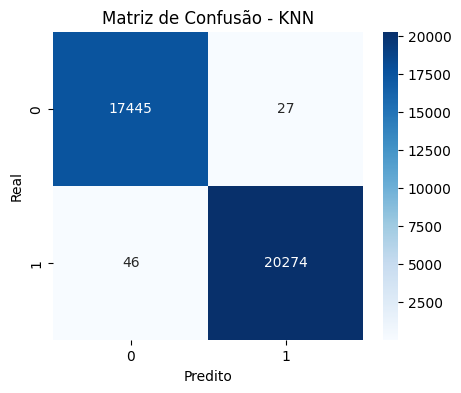

Relatório de Classificação - KNN:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17472
           1       1.00      1.00      1.00     20320

    accuracy                           1.00     37792
   macro avg       1.00      1.00      1.00     37792
weighted avg       1.00      1.00      1.00     37792



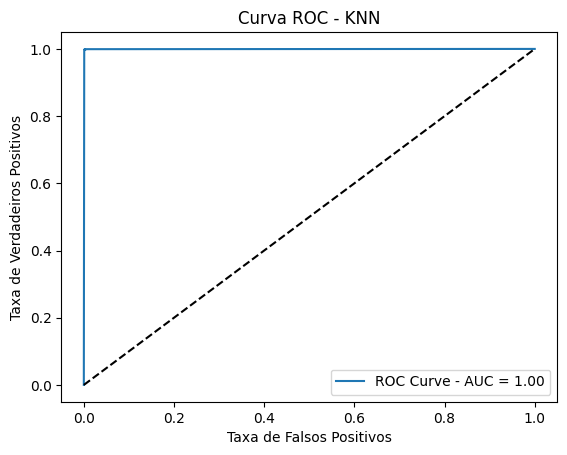

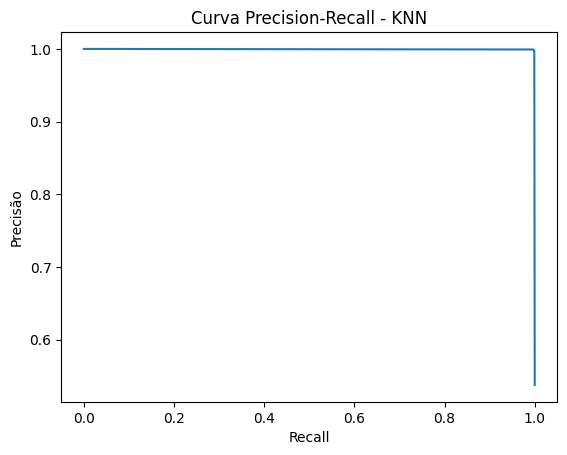

In [ ]:
avaliar_modelo(
    knn_model,
    X_train,
    Y_train,
    X_test,
    Y_test,
    nome_modelo="KNN"
)

In [ ]:
accuracies = []
precisions = []
recalls = []
f1s = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(kf.split(X, Y), start=1):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    Y_train_fold, Y_test_fold = Y.iloc[train_index], Y.iloc[test_index]

    scaler_fold = StandardScaler()
    X_train_fold = scaler_fold.fit_transform(X_train_fold)
    X_test_fold = scaler_fold.transform(X_test_fold)

    knn_fold = KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        metric='minkowski',
        p=2
    )

    knn_fold.fit(X_train_fold, Y_train_fold)

    Y_pred = knn_fold.predict(X_test_fold)

    acc = accuracy_score(Y_test_fold, Y_pred)
    prec = precision_score(Y_test_fold, Y_pred)
    rec = recall_score(Y_test_fold, Y_pred)
    f1 = f1_score(Y_test_fold, Y_pred)

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

    print(f"Fold {fold} — Acurácia: {acc:.6f}, Precisão: {prec:.6f}, Recall: {rec:.6f}, F1: {f1:.6f}")

print("\n--- MÉDIAS DA VALIDAÇÃO CRUZADA ---")
print("Acurácia média:", np.mean(accuracies))
print("Precisão média:", np.mean(precisions))
print("Recall médio:", np.mean(recalls))
print("F1-score médio:", np.mean(f1s))

Fold 1 — Acurácia: 0.998174, Precisão: 0.998737, Recall: 0.997847, F1: 0.998292
Fold 2 — Acurácia: 0.998770, Precisão: 0.999405, Recall: 0.998292, F1: 0.998849
Fold 3 — Acurácia: 0.998135, Precisão: 0.998811, Recall: 0.997698, F1: 0.998254
Fold 4 — Acurácia: 0.998373, Precisão: 0.998737, Recall: 0.998218, F1: 0.998477
Fold 5 — Acurácia: 0.998412, Precisão: 0.999034, Recall: 0.997995, F1: 0.998514

--- MÉDIAS DA VALIDAÇÃO CRUZADA ---
Acurácia média: 0.9983726674732984
Precisão média: 0.9989447395600234
Recall médio: 0.9980101895203239
F1-score médio: 0.9984772334027949


## **7. Conclusão**

---



Os experimentos realizados demonstraram a eficácia do algoritmo de Machine Learning K-Nearest Neighbors (KNN) aplicado à detecção de intrusões em redes de computadores, utilizando o conjunto de dados NSL-KDD como base. O modelo supervisionado foi empregado com o objetivo de identificar padrões capazes de distinguir tráfego normal de atividades maliciosas.

Durante a fase de treinamento e avaliação, o modelo KNN apresentou desempenho extremamente elevado, com métricas próximas de perfeição. A acurácia global obtida foi próxima de 100%, acompanhada de valores igualmente elevados de precisão, recall e F1-score, evidenciando a capacidade do modelo em aprender de forma eficiente as características presentes no conjunto de dados. A matriz de confusão revelou um número muito reduzido de erros de classificação, com poucos falsos positivos e falsos negativos em relação ao total de instâncias analisadas, demonstrando alta confiabilidade nas predições realizadas.

Além disso, as curvas ROC e Precision-Recall indicaram excelente capacidade discriminativa, com área sob a curva (AUC) igual a 1.00 e comportamento próximo do ideal ao longo de todo o intervalo, evidenciando simultaneamente alta precisão e alta sensibilidade do modelo. Os resultados da validação cruzada também apresentaram métricas consistentes e com baixa variabilidade, confirmando a estabilidade do algoritmo em diferentes partições do conjunto de dados.

De modo geral, conclui-se que o algoritmo KNN se mostrou uma abordagem eficaz para a detecção de intrusões, sendo capaz de alcançar elevados níveis de precisão na classificação de tráfego de rede. No entanto, quando comparado a modelos mais avançados, como métodos baseados em ensemble, seu desempenho pode ser limitado em cenários mais complexos.

Como proposta para trabalhos futuros, sugere-se a investigação de diferentes valores do parâmetro k e métricas de distância, bem como a comparação com outros algoritmos mais robustos. Além disso, recomenda-se explorar abordagens que considerem a dimensão temporal do tráfego de rede e a classificação multiclasses dos diferentes tipos de ataques (DoS, Probe, U2R e R2L), ampliando o escopo e a aplicabilidade do modelo desenvolvido.